In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from monarch import Hatch
import pathlib

# Initialize model
input_dir = pathlib.Path.cwd() / "input_files"
input_example = input_dir / "human_simple"
beats = Hatch(input_example)

In [5]:
print("Growth type: " + beats.growth.type)
print("Baseline R_mvb: " + str(beats.growth.rmvb[0]))
print("Acute R_mvb: " + str(beats.growth.rmvb[1]))

Growth type: nonmechanic
Baseline R_mvb: 10000000000.0
Acute R_mvb: 10000000000.0


In [6]:
# Simulate growth
beats.let_it_grow()

In [7]:
beats.growth.outputs

,LVEDV,LVESV,LVEDP,LVESP,LVMaxP,LVMaxdP,LVMindP,LVSV,LVRF,LVEF,...,RVESVi,dLVEDV,dLVESV,dLVEF,dEDWthLfw,dESWthLfw,dEDWthRfw,dESWthRfw,dEDWthSw,dESWthSw
-1,5.790230e+16,5.790230e+16,3.603831e+06,3.603831e+06,3.865060e+06,-315250.902618,-338088.796290,0.000000e+00,1.488384e-10,0.000000e+00,...,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0,2.082418e+16,2.082418e+16,1.528792e+05,1.528792e+05,1.639611e+05,-13373.576904,-14342.441227,0.000000e+00,9.630621e-11,0.000000e+00,...,NaN,-0.640357,-0.640357,NaN,-0.999090,-0.999090,-0.999090,-0.999090,0.100883,0.100883
1,-1.813148e+17,-1.813148e+17,1.374593e+04,1.446906e+04,1.474234e+04,-1202.465751,-1289.579866,1.868637e+07,0.000000e+00,-1.030604e-10,...,NaN,-4.131391,-4.131391,-inf,-0.999984,-0.999983,-0.999984,-0.999983,1.364205,1.360598
2,-1.789290e+17,-1.789290e+17,1.930961e+04,2.046348e+04,2.070932e+04,-1689.165100,-1811.538752,7.307277e+07,0.000000e+00,-4.083897e-10,...,NaN,-4.090189,-4.090189,-inf,-0.999980,-0.999977,-0.999980,-0.999977,2.554149,2.547655
3,-1.765747e+17,-1.765747e+17,2.411129e+04,2.565467e+04,2.585907e+04,-2109.205805,-2262.009828,1.882143e+08,0.000000e+00,-1.065919e-09,...,NaN,-4.049529,-4.049529,-inf,-0.999976,-0.999973,-0.999976,-0.999973,3.749168,3.740162
4,-1.789608e+17,-1.789608e+17,2.797551e+04,2.983580e+04,3.000340e+04,-2447.239486,-2624.532782,3.768171e+08,0.000000e+00,-2.105584e-09,...,NaN,-4.090738,-4.090738,-inf,-0.999974,-0.999971,-0.999974,-0.999971,4.949657,4.937570
5,-1.797598e+17,-1.797598e+17,3.125397e+04,3.338547e+04,3.351950e+04,-2734.031808,-2932.102123,6.646951e+08,0.000000e+00,-3.697686e-09,...,NaN,-4.104536,-4.104536,-inf,-0.999973,-0.999970,-0.999973,-0.999970,6.155287,6.140248
6,-1.821890e+17,-1.821890e+17,3.384540e+04,3.619162e+04,3.629878e+04,-2960.723489,-3175.216769,1.058340e+09,0.000000e+00,-5.809024e-09,...,NaN,-4.146490,-4.146490,-inf,-0.999973,-0.999969,-0.999973,-0.999969,7.365792,7.348173
7,-1.766919e+17,-1.766919e+17,3.643490e+04,3.899398e+04,3.907598e+04,-3187.246300,-3418.150309,1.650035e+09,0.000000e+00,-9.338488e-09,...,NaN,-4.051552,-4.051552,-inf,-0.999973,-0.999969,-0.999973,-0.999969,8.582257,8.561389
8,-1.759101e+17,-1.759101e+17,3.827391e+04,4.098288e+04,4.104830e+04,-3348.118301,-3590.676876,2.377645e+09,0.000000e+00,-1.351626e-08,...,NaN,-4.038050,-4.038050,-inf,-0.999974,-0.999970,-0.999974,-0.999970,9.803506,9.779912


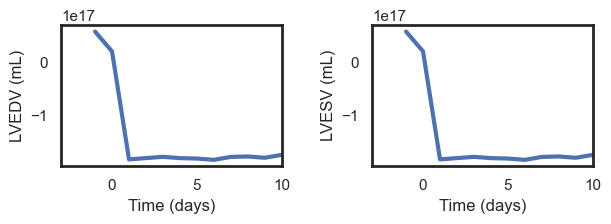

In [8]:
import monarch.metamophoses as meta

meta.plot_growth(beats, ["LVEDV", "LVESV"], units=["mL", "mL"])

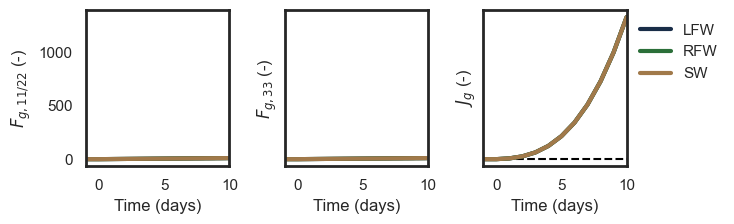

In [9]:
meta.plot_fg(beats)

[0.   0.01 0.02 0.03 0.04]


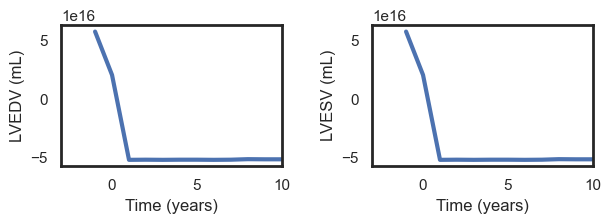

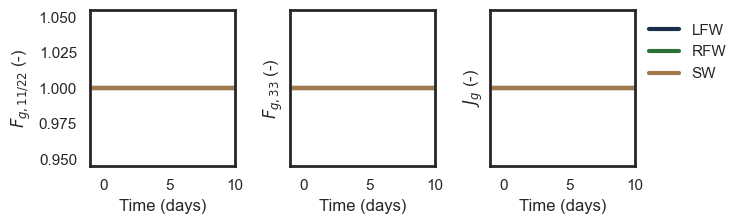

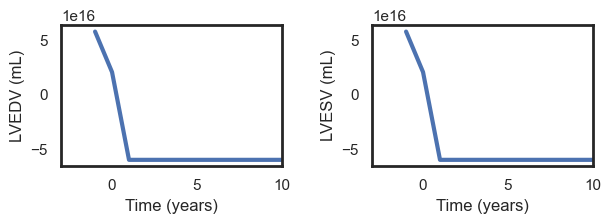

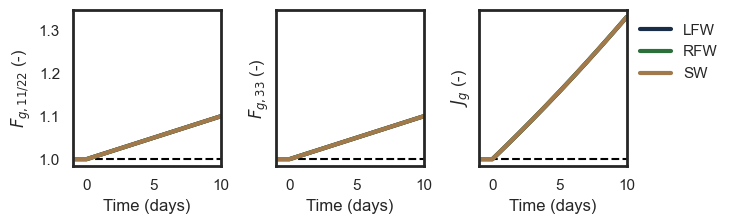

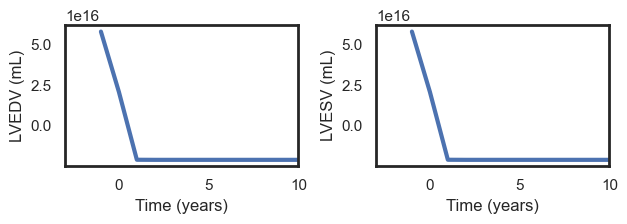

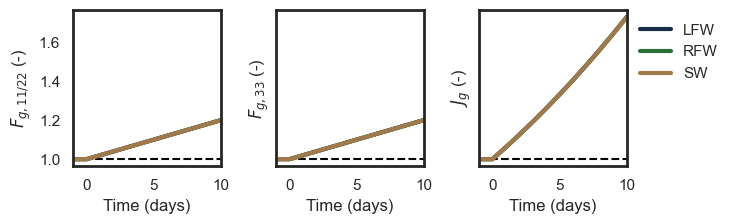

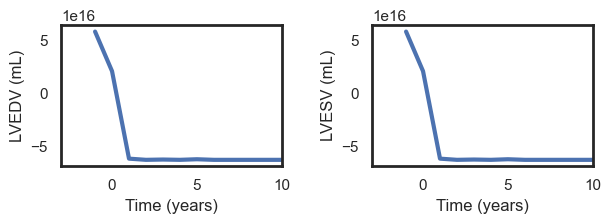

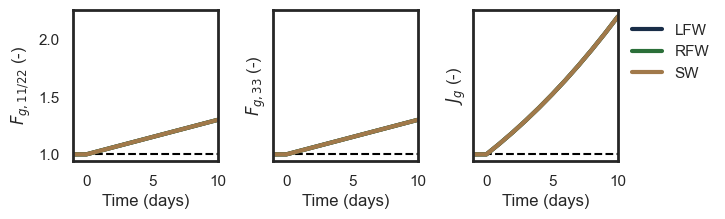

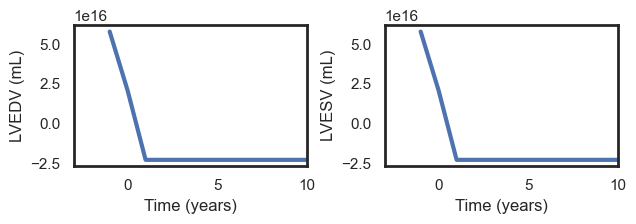

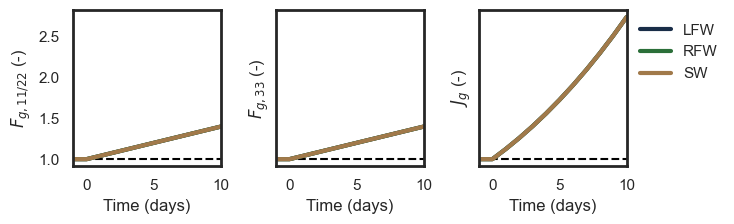

In [10]:
import numpy as np

beats = []
tau_vals = np.arange(0, 5, 1)
tau_vals = tau_vals / 100

print(tau_vals)
for tau in tau_vals:
    beat = Hatch(input_example)
    beat.change_pars({"tau_f+": tau})

    beat.just_beat_it()
    beats.append(beat)

    beat.let_it_grow()
    meta.plot_growth(beat, ["LVEDV", "LVESV"], units=["mL", "mL"], time_axis="Time (years)")
    meta.plot_fg(beat)